In [4]:
import bz2, pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import minimize_scalar
import sys
import os
sys.path.append(os.path.abspath('..'))
import synmorph as sm

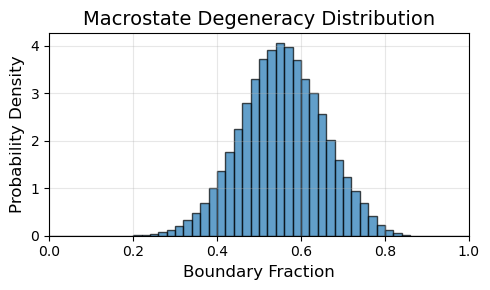

Integral of density: 1.000000


In [5]:
#============================================================
# Load simulation data and extract boundary fractions
# Plot density histogram of boundary fractions
#============================================================

tau_vals = [0.08, 0.16]
Dr_vals = 1/np.array(tau_vals)
v0_vals = [0.2, 0.4]
replicates = range(1,9)
dir_name = "Macrostate_Degeneracies"
burn = 2000  # burn-in timepoints to discard

# Extract only boundary_fraction (column 2) from each replicate
all_boundary_fractions = []

for Dr in Dr_vals:
    for v0 in v0_vals:
        for rep in replicates:
            simulation_file_name = f'Dr{round(Dr, 3)}_v{v0}_{rep}'
            file_path = f"./results/{dir_name}/{simulation_file_name}_simulation.pbz2"
            
            try:
                with bz2.BZ2File(file_path, "rb") as f:
                    sim = pickle.load(f)
                
                # Extract column 2 (boundary_fraction) after burn-in
                boundary_fraction = sim["phi_save"][burn:, 2]
                all_boundary_fractions.append(boundary_fraction)
                
            except Exception as e:
                print(f"Error loading {simulation_file_name}: {e}")

# Concatenate into single 1D array
boundary_fractions = np.concatenate(all_boundary_fractions)

# Create histogram with density=True
n_bins = 50
density, bin_edges = np.histogram(boundary_fractions, bins=n_bins, range=(0, 1), density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

# Plot density
plt.figure(figsize=(5, 3))
plt.bar(bin_centers, density, width=bin_width, alpha=0.7, edgecolor='black')
plt.xlabel('Boundary Fraction', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.title('Macrostate Degeneracy Distribution', fontsize=14)
plt.xlim(0, 1)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Verify normalization (should equal 1)
print(f"Integral of density: {np.sum(density * bin_width):.6f}")

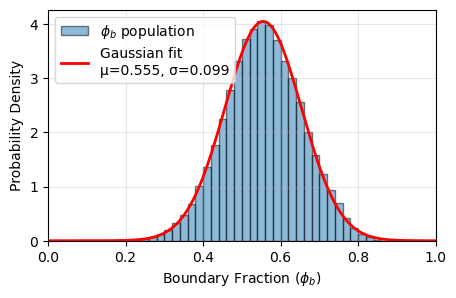

In [29]:
#============================================================
# Fit Gaussian to boundary fraction density histogram
#============================================================

# Fit directly to the raw data (most accurate)
mu_fit, sigma_fit = norm.fit(boundary_fractions)

# Generate fitted PDF
x_smooth = np.linspace(0, 1, 1000)
y_fit = norm.pdf(x_smooth, mu_fit, sigma_fit)

# Plot
plt.figure(figsize=(5, 3))
plt.hist(boundary_fractions, bins=n_bins, range=(0, 1), density=True, 
         alpha=0.5, label=r'$\phi_b$ population', edgecolor='black')
plt.plot(x_smooth, y_fit, 'r-', linewidth=2, 
         label=f'Gaussian fit\nμ={mu_fit:.3f}, σ={sigma_fit:.3f}')
plt.xlabel(r'Boundary Fraction ($\phi_b$)')
plt.ylabel('Probability Density')
plt.legend()
plt.xlim(0, 1)
plt.grid(alpha=0.3)
plt.show()

In [7]:
#============================================================
# Create Gaussian interpolation function to use as degeneracy factors
#============================================================

# Fit Gaussian
mu_fit, sigma_fit = norm.fit(boundary_fractions)

# Create a frozen distribution (acts as a function)
gaussian_interp = norm(loc=mu_fit, scale=sigma_fit)

# Now you can plug in any value(s) from 0 to 1
phib_value = 0.5
density_at_phib = gaussian_interp.pdf(phib_value)
print(f"Density at φ_b={phib_value}: {density_at_phib:.6f}")

# Works with arrays too
phib_array = np.array([0.0, 0.2, 0.5, 0.65, 0.8, 0.99, 1])
densities = gaussian_interp.pdf(phib_array)
print(f"Densities at φ_b={phib_array}: {densities}")

# Also get CDF (cumulative probability)
cdf_at_phib = gaussian_interp.cdf(phib_array)
print(f"CDF at φ_b={phib_value}: {cdf_at_phib}")

Density at φ_b=0.5: 3.467122
Densities at φ_b=[0.   0.2  0.5  0.65 0.8  0.99 1.  ]: [5.35113806e-07 6.22020416e-03 3.46712158e+00 2.53926662e+00
 1.83605442e-01 2.37303035e-04 1.50862397e-04]
CDF at φ_b=0.5: [9.10087153e-09 1.59461931e-04 2.89057342e-01 8.32852920e-01
 9.93561297e-01 9.99994939e-01 9.99996849e-01]


In [32]:
# ------------------------------------------------------------
# 1. Provide your interpolated degeneracy function g(phi_b)
# ------------------------------------------------------------
# Example:
# deg_func = lambda phi: g_interp(phi)
# (Replace this with your real degeneracy interpolant)
#
# For safety, ensure g(phi) >= 0 and normalized externally!
# ------------------------------------------------------------

def boltzmann_pdf(phi, lam, deg_func):
    """
    Compute g(phi) * exp(-lam * phi) / Z in a numerically stable way.
    """
    logw = np.log(deg_func(phi) + 1e-300) - lam * phi

    # log-sum-exp for continuous normalization        
    maxlog = np.max(logw)
    Z = np.trapz(np.exp(logw - maxlog), phi)
    logZ = np.log(Z) + maxlog

    return np.exp(logw - logZ)


# ------------------------------------------------------------
# 2. Negative log likelihood for fitting lam
# ------------------------------------------------------------

def neg_log_likelihood(lam, samples, deg_func, phi_grid):
    logw = np.log(deg_func(samples) + 1e-300) - lam * samples

    # compute normalization using the grid
    logw_grid = np.log(deg_func(phi_grid) + 1e-300) - lam * phi_grid
    maxlog = np.max(logw_grid)
    Z = np.trapz(np.exp(logw_grid - maxlog), phi_grid)
    logZ = np.log(Z) + maxlog

    # log likelihood: sum(log P(samples))
    return -(np.sum(logw - logZ))


def fit_lambda(samples, deg_func, phi_grid):
    """
    Fit lambda using bounded scalar minimization.
    You can adjust fitting range if needed.
    """
    res = minimize_scalar(
        lambda lam: neg_log_likelihood(lam, samples, deg_func, phi_grid),
        bounds=(-20, 50),  # Allow negative or positive slopes
        method='bounded'
    )
    return res.x


# ------------------------------------------------------------
# 3. Main function: sample, fit, plot
# ------------------------------------------------------------

def fit_and_plot_boltzmann(phi_save, deg_func, args, n_samples=50, nbins=15):
    # Sample ~50 values
    samples = np.random.choice(phi_save, size=n_samples, replace=False)

    # Build a grid for plotting
    phi_grid = np.linspace(0, 1, 400)

    # Fit the lambda coefficient
    lam_fit = fit_lambda(samples, deg_func, phi_grid=phi_grid)
    print("Fitted λ (energy/temperature coefficient):", lam_fit)

    pdf_fit = boltzmann_pdf(phi_grid, lam_fit, deg_func)

    # Plot comparison
    plt.figure(figsize=(5,3))
    plt.hist(samples, bins=nbins, density=True,
             alpha=0.55, label=f"Sampled φ_b histogram\nDr={args[0]} v0={args[1]}")

    plt.plot(phi_grid, pdf_fit, 'r-', linewidth=3,
             label="Fitted Boltzmann: "+r"$\beta$"+ f"={lam_fit:.2f}")

    plt.xlabel("φ_b")
    plt.ylabel("Probability density")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return lam_fit


dict_keys(['simulation_params', 'save_options', 't', 't_span', 't_span_save', 'nt', 'nts', 'x_save', 'tri_save', 'var_save', 'grn', 'phi_save', 'ejected_save', 'date', 'name', 'id', 'save_dir', 'save_dir_pickled', 'save_dir_plots'])
Fitted λ (energy/temperature coefficient): 49.99999519305238


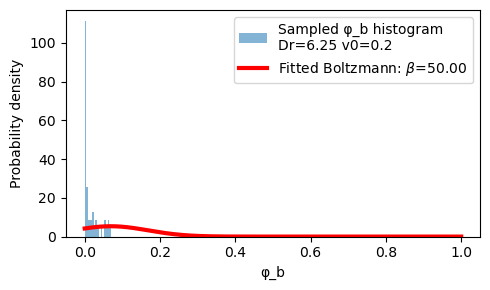

In [38]:
tau_vals = [0.04, 0.08, 0.16]
Dr_vals = 1/np.array(tau_vals)
v0_vals = [0.2, 0.4, 0.8]
Dr = round(Dr_vals[2], 3)
v0 = v0_vals[0]
replicates = range(1,26)
rep = replicates[7]
simulation_file_name = f'Dr{Dr}_v{v0}_{rep}'
dir_name = "Multiseed"
burn = 40
args = (Dr, v0, rep)

with bz2.BZ2File(f"./results/{dir_name}/{simulation_file_name}_simulation.pbz2", "rb") as f:
    sim = pickle.load(f)

print(sim.keys())

phi_save = sim["phi_save"][burn:, 2]

degeneracy_dist = gaussian_interp.pdf

if not np.any(sim["ejected_save"]):
    fit_and_plot_boltzmann(phi_save, degeneracy_dist, args)
else:
    print("Ejections detected; skipping Boltzmann fit.")

In [42]:
# -------------------------------------------------------------
# FITTING λ ACROSS ALL REPLICATES AND ACTIVITY PARAMETERS AND PLOTTING
# -------------------------------------------------------------

def fit_lambda_only(phi_save, deg_func):
    samples = np.random.choice(phi_save, size=50, replace=False)
    phi_grid = np.linspace(0, 1, 400)
    lam_fit = fit_lambda(samples, deg_func, phi_grid)
    return lam_fit

def plot_lambda_heatmap(Dr_vals, v0_vals, mean_lam):
    plt.figure(figsize=(6,4))

    # Flip array vertically so highest Dr appears at the top
    mean_lam_plot = mean_lam[::-1]

    im = plt.imshow(
        mean_lam_plot,
        cmap="viridis",
        aspect="auto",
        origin="upper"     # so row 0 is at the top
    )

    # Set ticks at center of each cell
    plt.xticks(
        ticks=np.arange(len(v0_vals)),
        labels=v0_vals
    )
    plt.yticks(
        ticks=np.arange(len(Dr_vals)),
        labels=Dr_vals[::-1]    # reversed to match the flipped array
    )

    plt.colorbar(im, label=r"Mean $\frac{1}{\beta} \propto T_{eff}$ across replicates")
    plt.xlabel("v0")
    plt.ylabel("Dr")
    plt.tight_layout()
    plt.show()



In [40]:
import numpy as np
import bz2, pickle
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# -------------------------------------------------------------
# PARAMETERS
# -------------------------------------------------------------
tau_vals = [0.04, 0.08, 0.16]
Dr_vals = np.round(1 / np.array(tau_vals), 3)
v0_vals = [0.2, 0.4, 0.8]
replicates = range(1, 26)
burn = 40
dir_name = "Multiseed"
Y_LX = -0.1
Y_MX = -0.3
deltaE = Y_LX - Y_MX

# degeneracy distribution from your Gaussian interpolation
degeneracy_dist = gaussian_interp.pdf

# -------------------------------------------------------------
# STORAGE FOR RESULTS
# lam_values[Dr_index, v0_index, replicate_index] = fitted λ
# -------------------------------------------------------------
lam_values = np.full((len(Dr_vals), len(v0_vals), len(replicates)), np.nan)


# -------------------------------------------------------------
# MAIN LOOPS
# -------------------------------------------------------------
for iD, Dr in enumerate(Dr_vals):
    for iv, v0 in enumerate(v0_vals):

        # Skip rule: for Dr = 25 → skip v0 = 0.2
        if np.isclose(Dr, Dr_vals[0]) and np.isclose(v0, 0.2):
            print(f"Skipping Dr={Dr}, v0={v0}")
            continue

        for ir, rep in enumerate(replicates):

            simulation_file_name = f"Dr{Dr}_v{v0}_{rep}"
            filepath = f"./results/{dir_name}/{simulation_file_name}_simulation.pbz2"

            try:
                with bz2.BZ2File(filepath, "rb") as f:
                    sim = pickle.load(f)
            except FileNotFoundError:
                print(f"Missing file: {filepath} — skipping.")
                continue

            # check for ejected cells
            if np.any(sim["ejected_save"]):
                print(f"Ejections detected: Dr={Dr}, v0={v0}, rep={rep} → SKIPPED.")
                continue

            # extract phi_b time series
            phi_save = sim["phi_save"][burn:, 2]

            # fit λ
            lam_fit = fit_lambda_only(phi_save, degeneracy_dist)  # see note below
            lam_values[iD, iv, ir] = lam_fit

            print(f"Fit: Dr={Dr}, v0={v0}, rep={rep}, λ={lam_fit:.4f}")

mean_lam = np.nanmean(lam_values, axis=2)




Skipping Dr=25.0, v0=0.2
Fit: Dr=25.0, v0=0.4, rep=1, λ=50.0000
Fit: Dr=25.0, v0=0.4, rep=2, λ=50.0000
Fit: Dr=25.0, v0=0.4, rep=3, λ=50.0000
Ejections detected: Dr=25.0, v0=0.4, rep=4 → SKIPPED.
Fit: Dr=25.0, v0=0.4, rep=5, λ=50.0000
Fit: Dr=25.0, v0=0.4, rep=6, λ=50.0000
Fit: Dr=25.0, v0=0.4, rep=7, λ=50.0000
Fit: Dr=25.0, v0=0.4, rep=8, λ=50.0000
Fit: Dr=25.0, v0=0.4, rep=9, λ=50.0000
Fit: Dr=25.0, v0=0.4, rep=10, λ=50.0000
Fit: Dr=25.0, v0=0.4, rep=11, λ=50.0000
Fit: Dr=25.0, v0=0.4, rep=12, λ=50.0000
Fit: Dr=25.0, v0=0.4, rep=13, λ=50.0000
Fit: Dr=25.0, v0=0.4, rep=14, λ=50.0000
Fit: Dr=25.0, v0=0.4, rep=15, λ=50.0000
Fit: Dr=25.0, v0=0.4, rep=16, λ=50.0000
Fit: Dr=25.0, v0=0.4, rep=17, λ=50.0000
Fit: Dr=25.0, v0=0.4, rep=18, λ=50.0000
Fit: Dr=25.0, v0=0.4, rep=19, λ=50.0000
Fit: Dr=25.0, v0=0.4, rep=20, λ=50.0000
Fit: Dr=25.0, v0=0.4, rep=21, λ=50.0000
Fit: Dr=25.0, v0=0.4, rep=22, λ=50.0000
Fit: Dr=25.0, v0=0.4, rep=23, λ=50.0000
Ejections detected: Dr=25.0, v0=0.4, rep=24 → SKI

/var/folders/wg/y5dl1b4s7g79_2g2dm6tjgqw0000gp/T/ipykernel_44126/3537556545.py:66: RuntimeWarning: Mean of empty slice
  mean_lam = np.nanmean(lam_values, axis=2)


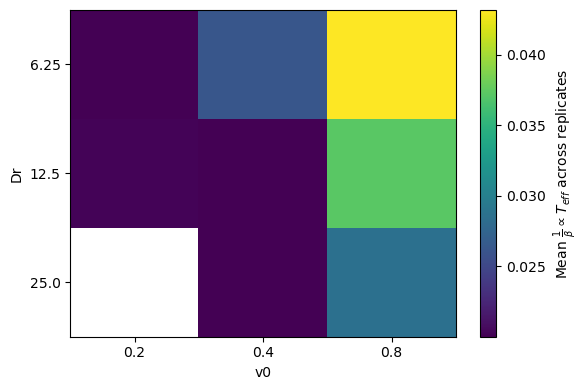

In [43]:

Y_LX = -0.1
Y_MX = -0.3
deltaE = Y_LX - Y_MX
mean_active_temp = 1 / mean_lam

plot_lambda_heatmap(Dr_vals, v0_vals, mean_active_temp)

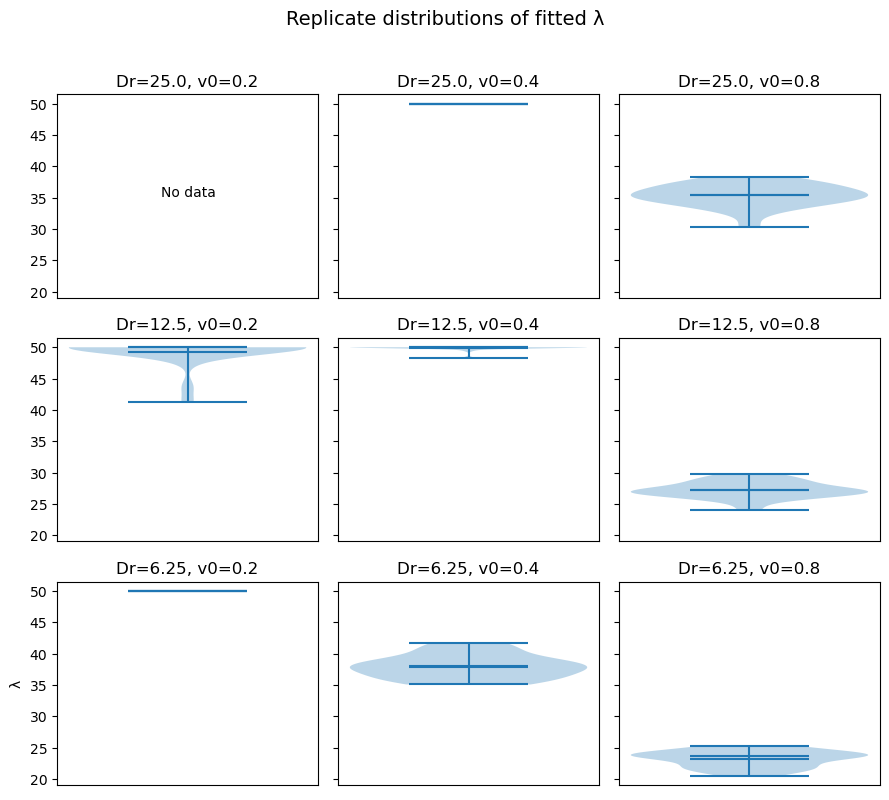

In [ ]:
# -------------------------------------------------------------
# VIOLIN PLOTS OF λ DISTRIBUTIONS ACROSS REPLICATES
# -------------------------------------------------------------
def plot_lambda_violins(Dr_vals, v0_vals, lam_values):
    nDr = len(Dr_vals)
    nv0 = len(v0_vals)

    fig, axes = plt.subplots(nDr, nv0, figsize=(3*nv0, 2.6*nDr), sharey=True)

    if nDr == 1 and nv0 == 1:
        axes = np.array([[axes]])

    for i in range(nDr):
        for j in range(nv0):
            ax = axes[i, j]

            lam_ij = lam_values[i, j, :]
            lam_clean = lam_ij[~np.isnan(lam_ij)]

            if len(lam_clean) > 0:
                ax.violinplot(lam_clean, showmeans=True, showmedians=True)
            else:
                ax.text(0.4, 0.5, "No data", transform=ax.transAxes)

            ax.set_title(f"Dr={Dr_vals[i]}, v0={v0_vals[j]}")
            ax.set_xticks([])

    axes[nDr-1, 0].set_ylabel("λ")
    plt.suptitle("Replicate distributions of fitted λ", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()
    
plot_lambda_violins(Dr_vals, v0_vals, lam_values)